# XTRIUM Material GNN Prototyping Model

This notebook performs comprehensive EDA, feature engineering, and builds a Graph Neural Network prototyping model for material discovery.

**Project Context**: XTRIUM is an AI-driven platform for material innovation that uses GNNs to:
- Match materials to novel applications
- Identify material substitutes
- Optimize supply chains
- Drive sustainability insights


In [1]:
# Import required libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Find repository root and load data
def find_repo_root(start=None, markers=('.git', 'environment.yml', 'requirements.txt', 'README.md')):
    """Walk upward from `start` (or cwd) until a marker file/dir is found."""
    if start is None:
        start = os.getcwd()
    cur = os.path.abspath(start)
    while True:
        for m in markers:
            if os.path.exists(os.path.join(cur, m)):
                return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            return None
        cur = parent

repo_root = find_repo_root()
if repo_root is None:
    repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

DATA_PATH = os.path.join(repo_root, 'data', 'raw', 'materials.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"materials.csv not found at {DATA_PATH}. Checked repo root: {repo_root}")

print(f'Repository root: {repo_root}')
print(f'Data path: {DATA_PATH}')


Repository root: /Users/nk/Downloads/GNN/xtrium-material-gnn
Data path: /Users/nk/Downloads/GNN/xtrium-material-gnn/data/raw/materials.csv


In [3]:
# Load the materials dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
print(df.head())


Dataset loaded successfully!
Shape: 30 rows × 255 columns

First few rows:
   Id                                      Material_Name  \
0   1  1/4" Rohacell 31 foam/carbon cloth Aircraft Sk...   
1   2  1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...   
2   3  1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...   
3   4  1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...   
4   5  1,3-Bis(3,4-dicarboxyphenoxy-4-phenyl-2-propyl...   

                         Database_Source  \
0  NASA Langley Research Center Database   
1  NASA Langley Research Center Database   
2  NASA Langley Research Center Database   
3  NASA Langley Research Center Database   
4  NASA Langley Research Center Database   

                                       Category  \
0  Structural Organic Composites | Description:   
1                     Polyamides | Description:   
2                     Polyamides | Description:   
3                     Polyamides | Description:   
4                     Polyamides | Descripti

In [4]:
# Basic dataset information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"\nData Types:")
print(df.dtypes.value_counts())
print(f"\nColumn Names (first 20):")
print(df.columns.tolist()[:20])


DATASET OVERVIEW

Total Records: 30
Total Features: 255

Data Types:
object     176
float64     78
int64        1
Name: count, dtype: int64

Column Names (first 20):
['Id', 'Material_Name', 'Database_Source', 'Category', 'URL', 'Name', 'Database', 'Composition', 'Manufacturer', 'Technical_Readiness_Level', 'Last_Modified', 'Description', 'Point_of_Contact', 'Property_References', 'General_References', 'Density_Value', 'Density_Units', 'Density_Uncertainty', 'Density_Source', 'Density_STP']


MISSING VALUES ANALYSIS

Columns with missing values: 243

Top 20 columns with highest missing values:
                                                Column  Missing Count  \
127        Tensile_Modulus_Thru_the_Thickness_10_Value             29   
140                  Compressive_Strength_In_Plane_STP             29   
130          Tensile_Modulus_Thru_the_Thickness_10_STP             29   
131  Tensile_Modulus_Thru_the_Thickness_10_Last_Mod...             29   
132                  Tensile_Modulus_In_Plane_11_Value             29   
133                  Tensile_Modulus_In_Plane_11_Units             29   
134                 Tensile_Modulus_In_Plane_11_Source             29   
135                    Tensile_Modulus_In_Plane_11_STP             29   
136          Tensile_Modulus_In_Plane_11_Last_Modified             29   
137                Compressive_Strength_In_Plane_Value             29   
138                Compressive_Strength_In_Plane_Units             29   
139               Com

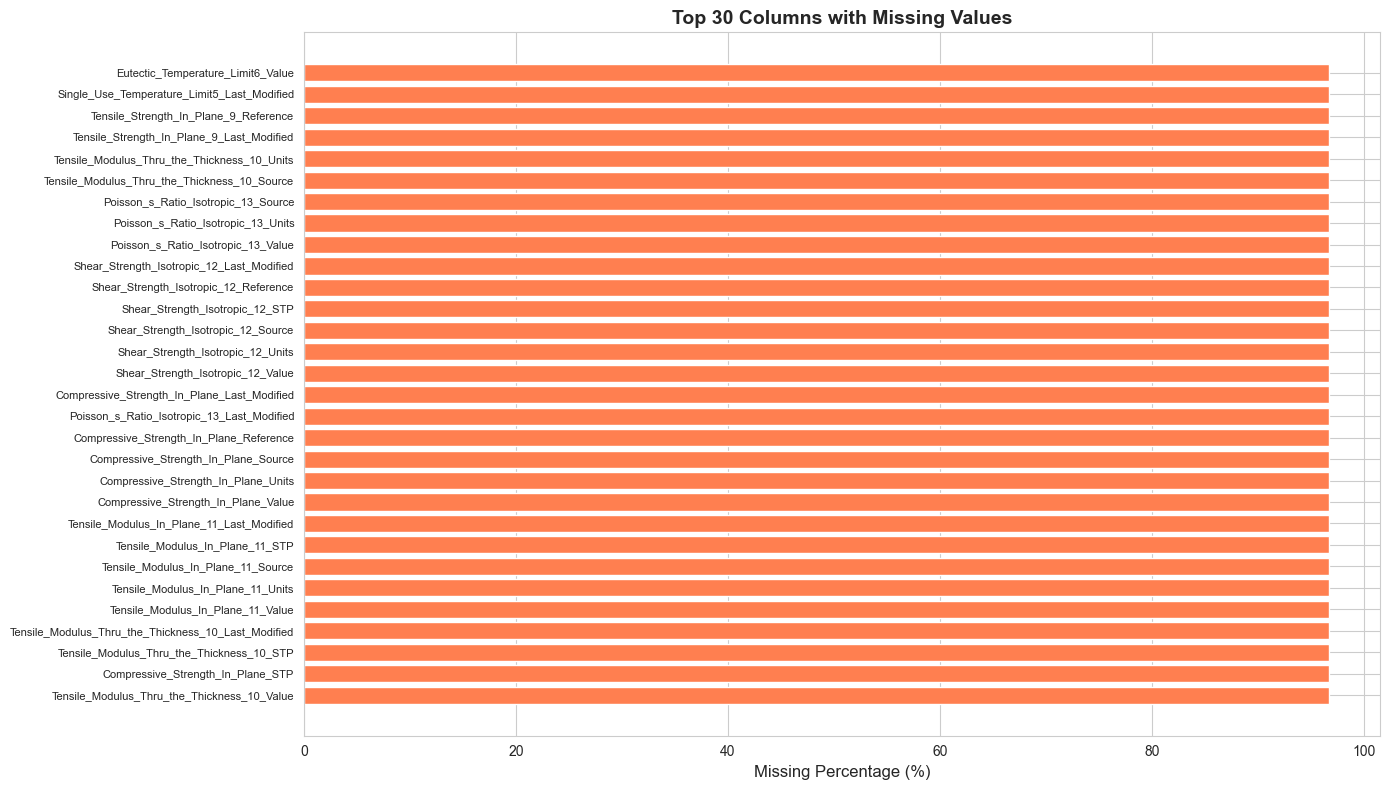

In [5]:
# Missing values analysis
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
}).sort_values('Missing Percentage', ascending=False)

print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
print(f"\nColumns with missing values: {len(missing_df[missing_df['Missing Count'] > 0])}")
print(f"\nTop 20 columns with highest missing values:")
print(missing_df.head(20))

# Visualize missing values
plt.figure(figsize=(14, 8))
top_missing = missing_df.head(30)
plt.barh(range(len(top_missing)), top_missing['Missing Percentage'], color='coral')
plt.yticks(range(len(top_missing)), top_missing['Column'], fontsize=8)
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.title('Top 30 Columns with Missing Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
# Identify column types
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Further categorize text vs categorical
text_cols = [c for c in categorical_cols if df[c].nunique() > 20 and df[c].notna().sum() > 0]
cat_cols = [c for c in categorical_cols if df[c].nunique() <= 20 and df[c].notna().sum() > 0]

print("=" * 60)
print("COLUMN CATEGORIZATION")
print("=" * 60)
print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns (low cardinality): {len(cat_cols)}")
print(f"Text columns (high cardinality): {len(text_cols)}")
print(f"\nSample numeric columns: {numeric_cols[:10]}")
print(f"\nSample categorical columns: {cat_cols[:10]}")
print(f"\nText columns: {text_cols}")


COLUMN CATEGORIZATION

Numeric columns: 79
Categorical columns (low cardinality): 172
Text columns (high cardinality): 4

Sample numeric columns: ['Id', 'Density_Value', 'Density_Uncertainty', 'Density_Reference', 'Thermal_Conductivity_Thru_the_Thickness_Value', 'Thermal_Conductivity_Thru_the_Thickness_Uncertainty', 'Thermal_Conductivity_Thru_the_Thickness_Reference', 'Thermal_Conductivity_In_Plane_Value', 'Thermal_Conductivity_In_Plane_Uncertainty', 'Thermal_Conductivity_In_Plane_Reference']

Sample categorical columns: ['Database_Source', 'Category', 'Database', 'Composition', 'Manufacturer', 'Technical_Readiness_Level', 'Last_Modified', 'Point_of_Contact', 'Property_References', 'General_References']

Text columns: ['Material_Name', 'URL', 'Name', 'Description']


In [7]:
# Extract key material property columns
# Properties typically have pattern: PropertyName_Value, PropertyName_Units, PropertyName_Source, etc.

property_value_cols = [col for col in df.columns if col.endswith('_Value') and col in numeric_cols]
property_units_cols = [col for col in df.columns if col.endswith('_Units')]
property_source_cols = [col for col in df.columns if col.endswith('_Source')]

print("=" * 60)
print("MATERIAL PROPERTIES IDENTIFICATION")
print("=" * 60)
print(f"\nProperty Value columns: {len(property_value_cols)}")
print(f"Property Units columns: {len(property_units_cols)}")
print(f"Property Source columns: {len(property_source_cols)}")
print(f"\nSample property values: {property_value_cols[:15]}")


MATERIAL PROPERTIES IDENTIFICATION

Property Value columns: 40
Property Units columns: 40
Property Source columns: 41

Sample property values: ['Density_Value', 'Thermal_Conductivity_Thru_the_Thickness_Value', 'Thermal_Conductivity_In_Plane_Value', 'Specific_Heat_Value', 'Tensile_Strength_Isotropic_1_Value', 'Tensile_Yield_Strength_Isotropic_2_Value', 'Tensile_Modulus_In_Plane_3_Value', 'Tensile_Modulus_Isotropic_2_Value', 'Coefficient_of_Thermal_Expansion_Isotropic_3_Value', 'Thermal_Conductivity_Thru_the_Thickness_1_Value', 'Thermal_Conductivity_In_Plane_2_Value', 'Emissivity3_Value', 'Multiple_Use_Temperature_Limit4_Value', 'Single_Use_Temperature_Limit5_Value', 'Eutectic_Temperature_Limit6_Value']


In [8]:
# Analyze key categorical features
print("=" * 60)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 60)

key_categorical = ['Category', 'Database_Source', 'Database', 'Manufacturer', 'Technical_Readiness_Level']
for col in key_categorical:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")
        if df[col].nunique() <= 20:
            print(f"  Value counts:")
            print(df[col].value_counts().head(10))


CATEGORICAL FEATURES ANALYSIS

Category:
  Unique values: 8
  Missing: 0 (0.0%)
  Value counts:
Category
Polyamides | Description:                                                14
Carbon-Phenolics | Description:                                           6
Other | Description:                                                      4
Plastics | Description:                                                   2
Structural Organic Composites | Description:                              1
Ultra-High Temperature Ceramics | Description:                            1
Silicon-Based Reusable Composites: Rigid Ceramic Tiles | Description:     1
Carbon-Based Reusable Composites: Carbon-Carbons | Description:           1
Name: count, dtype: int64

Database_Source:
  Unique values: 4
  Missing: 0 (0.0%)
  Value counts:
Database_Source
NASA Langley Research Center Database     16
NASA JSC PathFinder Materials              7
K&K Associates Materials                   5
NASA Ames Thermal Protection Material

In [9]:
# Statistical summary of numeric properties
print("=" * 60)
print("NUMERIC PROPERTIES SUMMARY")
print("=" * 60)

# Filter to property value columns that have at least some non-null values
valid_property_cols = [col for col in property_value_cols if df[col].notna().sum() > 0]

print(f"\nProperties with data: {len(valid_property_cols)}")
print(f"\nStatistical summary of key properties:")
summary_df = df[valid_property_cols].describe().T
summary_df['non_null_count'] = df[valid_property_cols].notna().sum()
summary_df = summary_df.sort_values('non_null_count', ascending=False)
print(summary_df.head(20))


NUMERIC PROPERTIES SUMMARY

Properties with data: 40

Statistical summary of key properties:
                                                    count          mean  \
Density_Value                                        15.0  1.367533e+03   
Thermal_Conductivity_Isotropic_Value                 11.0  9.897273e-01   
Specific_Heat_Value                                  10.0  1.156800e+03   
Tensile_Strength_Isotropic_1_Value                   10.0  1.277600e+08   
Tensile_Yield_Strength_Isotropic_2_Value              5.0  9.272000e+07   
Tensile_Modulus_In_Plane_3_Value                      5.0  2.758000e+09   
Tensile_Modulus_Isotropic_2_Value                     5.0  4.586000e+09   
Emissivity1_Value                                     4.0  5.950000e-01   
Absorptivity2_Value                                   4.0  9.250000e-02   
Tensile_Strength_Isotropic_3_Value                    4.0  9.700000e+07   
Tensile_Modulus_Isotropic_4_Value                     4.0  3.500000e+09   
Coeffic

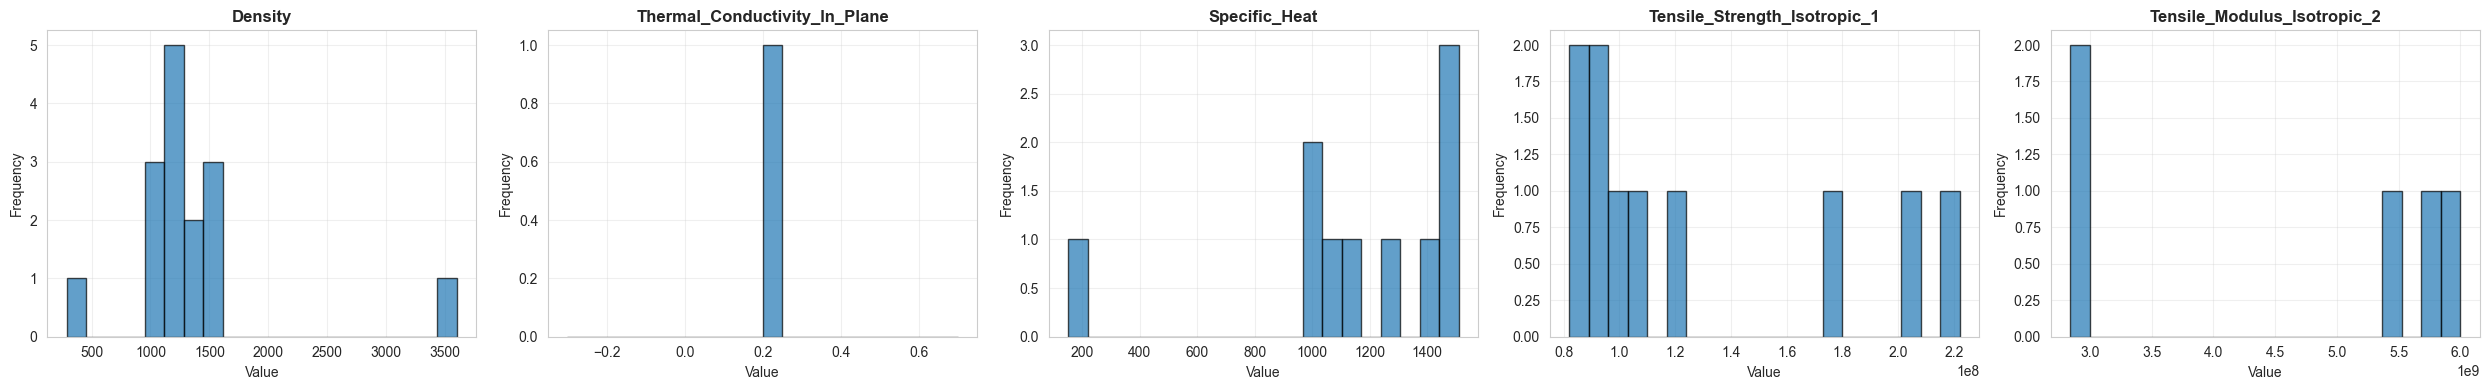

In [10]:
# Visualize distributions of key material properties
key_properties = ['Density_Value', 'Thermal_Conductivity_In_Plane_Value', 
                  'Specific_Heat_Value', 'Tensile_Strength_Isotropic_1_Value',
                  'Tensile_Modulus_Isotropic_2_Value']

available_props = [p for p in key_properties if p in df.columns and df[p].notna().sum() > 0]

if available_props:
    n_props = len(available_props)
    fig, axes = plt.subplots(1, n_props, figsize=(5*n_props, 4))
    if n_props == 1:
        axes = [axes]
    
    for idx, prop in enumerate(available_props):
        data = df[prop].dropna()
        axes[idx].hist(data, bins=20, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{prop.replace("_Value", "")}', fontweight='bold')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No key properties available for visualization")


In [11]:
# Feature Engineering: Create consolidated material property features
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create a copy for feature engineering
df_fe = df.copy()

# 1. Extract base property names (remove suffixes like _Value, _Units, etc.)
def extract_base_property(col_name):
    """Extract base property name from column name"""
    suffixes = ['_Value', '_Units', '_Uncertainty', '_Source', '_STP', '_Reference', '_Last_Modified']
    for suffix in suffixes:
        if col_name.endswith(suffix):
            return col_name.replace(suffix, '')
    return col_name

# 2. Create property completeness score (how many properties are available per material)
property_value_cols_available = [col for col in property_value_cols if col in df_fe.columns]
df_fe['property_completeness'] = df_fe[property_value_cols_available].notna().sum(axis=1) / len(property_value_cols_available)

print(f"\nProperty completeness score created")
print(f"Mean completeness: {df_fe['property_completeness'].mean():.3f}")
print(f"Std completeness: {df_fe['property_completeness'].std():.3f}")


FEATURE ENGINEERING

Property completeness score created
Mean completeness: 0.094
Std completeness: 0.070


In [12]:
# 3. Normalize key numeric properties (handle different units)
# For now, we'll work with the raw values and handle normalization later if needed

# 4. Create categorical encodings
from sklearn.preprocessing import LabelEncoder

# Encode key categorical features
categorical_to_encode = ['Category', 'Database_Source', 'Manufacturer', 'Technical_Readiness_Level']
label_encoders = {}

for col in categorical_to_encode:
    if col in df_fe.columns:
        le = LabelEncoder()
        # Fill NaN with 'Unknown' before encoding
        df_fe[col + '_encoded'] = le.fit_transform(df_fe[col].fillna('Unknown'))
        label_encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique values")

print(f"\nCategorical encoding completed")


Encoded Category: 8 unique values
Encoded Database_Source: 4 unique values
Encoded Manufacturer: 8 unique values
Encoded Technical_Readiness_Level: 3 unique values

Categorical encoding completed


In [13]:
# 5. Create material feature vector for similarity calculations
# Select most common properties that have reasonable coverage
property_coverage = {}
for col in property_value_cols:
    if col in df_fe.columns:
        coverage = df_fe[col].notna().sum() / len(df_fe)
        property_coverage[col] = coverage

# Select properties with at least 10% coverage
selected_properties = [prop for prop, cov in property_coverage.items() if cov >= 0.1]
selected_properties = sorted(selected_properties, key=lambda x: property_coverage[x], reverse=True)[:20]

print(f"\nSelected {len(selected_properties)} properties for feature vector (>=10% coverage)")
print(f"Properties: {[p.replace('_Value', '') for p in selected_properties[:10]]}...")

# Create feature matrix (fill missing with 0 for now, will use imputation later)
feature_matrix = df_fe[selected_properties].fillna(0).values

print(f"Feature matrix shape: {feature_matrix.shape}")



Selected 14 properties for feature vector (>=10% coverage)
Properties: ['Density', 'Thermal_Conductivity_Isotropic', 'Specific_Heat', 'Tensile_Strength_Isotropic_1', 'Tensile_Yield_Strength_Isotropic_2', 'Tensile_Modulus_In_Plane_3', 'Tensile_Modulus_Isotropic_2', 'Emissivity1', 'Absorptivity2', 'Tensile_Strength_Isotropic_3']...
Feature matrix shape: (30, 14)


In [14]:
# 6. Handle missing values in feature matrix using median imputation
from sklearn.impute import SimpleImputer

# Only impute where we have at least some values
imputer = SimpleImputer(strategy='median')
feature_matrix_imputed = imputer.fit_transform(feature_matrix)

# Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_matrix_normalized = scaler.fit_transform(feature_matrix_imputed)

print(f"Feature matrix normalized: {feature_matrix_normalized.shape}")
print(f"Mean: {feature_matrix_normalized.mean():.4f}, Std: {feature_matrix_normalized.std():.4f}")


Feature matrix normalized: (30, 14)
Mean: -0.0000, Std: 1.0000


In [15]:
# GRAPH CONSTRUCTION FOR GNN
print("=" * 60)
print("GRAPH CONSTRUCTION")
print("=" * 60)

# Calculate material similarity using cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(feature_matrix_normalized)
print(f"Similarity matrix shape: {similarity_matrix.shape}")

# Set similarity threshold for edges (top 20% of similarities)
similarity_threshold = np.percentile(similarity_matrix[similarity_matrix < 1.0], 80)
print(f"Similarity threshold (80th percentile): {similarity_threshold:.4f}")

# Create edge list
edges = []
edge_weights = []
for i in range(len(df_fe)):
    for j in range(i + 1, len(df_fe)):
        if similarity_matrix[i, j] > similarity_threshold:
            edges.append((i, j))
            edge_weights.append(similarity_matrix[i, j])

print(f"\nTotal edges created: {len(edges)}")
print(f"Average degree: {len(edges) * 2 / len(df_fe):.2f}")


GRAPH CONSTRUCTION
Similarity matrix shape: (30, 30)
Similarity threshold (80th percentile): 0.3854

Total edges created: 82
Average degree: 5.47


GRAPH STATISTICS
Number of nodes: 30
Number of edges: 82
Average degree: 5.47
Number of connected components: 5
Graph density: 0.1885


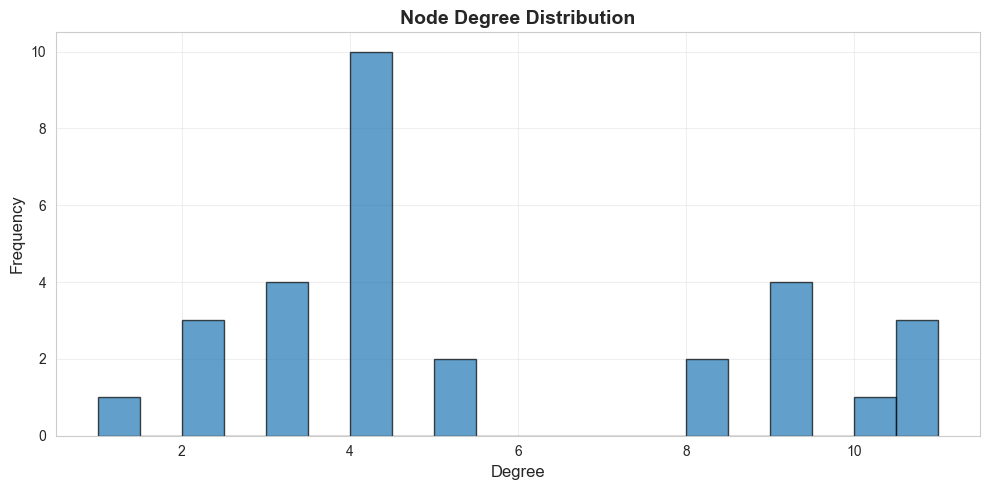

In [16]:
# Visualize graph statistics
import networkx as nx

# Create NetworkX graph for visualization
G = nx.Graph()
G.add_nodes_from(range(len(df_fe)))
G.add_edges_from(edges)

print("=" * 60)
print("GRAPH STATISTICS")
print("=" * 60)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"Number of connected components: {nx.number_connected_components(G)}")
print(f"Graph density: {nx.density(G):.4f}")

# Plot degree distribution
degrees = [G.degree(n) for n in G.nodes()]
plt.figure(figsize=(10, 5))
plt.hist(degrees, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Node Degree Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
# Prepare node features for GNN
# Combine normalized property features with categorical encodings

node_features_list = []

for idx in range(len(df_fe)):
    # Start with normalized property features
    features = list(feature_matrix_normalized[idx])
    
    # Add categorical encodings (normalized)
    for col in categorical_to_encode:
        if col + '_encoded' in df_fe.columns:
            encoded_val = df_fe[col + '_encoded'].iloc[idx]
            # One-hot encode (simplified - using encoded value as feature)
            features.append(encoded_val / len(label_encoders[col].classes_))  # Normalize
    
    # Add property completeness
    features.append(df_fe['property_completeness'].iloc[idx])
    
    node_features_list.append(features)

node_features = np.array(node_features_list)
print(f"Node features shape: {node_features.shape}")
print(f"Feature dimension: {node_features.shape[1]}")


Node features shape: (30, 19)
Feature dimension: 19


In [18]:
# Convert to PyTorch Geometric format
try:
    import torch
    from torch_geometric.data import Data
    from torch_geometric.utils import to_networkx
    from torch_geometric.nn import GCNConv, GATConv
    import torch.nn.functional as F
    
    print("PyTorch Geometric imported successfully!")
    
    # Convert edge list to PyTorch format (bidirectional for undirected graph)
    # Create forward and reverse edges
    edge_list_forward = [[e[0] for e in edges], [e[1] for e in edges]]
    edge_list_reverse = [[e[1] for e in edges], [e[0] for e in edges]]
    # Concatenate properly: [[src1, src2, ...], [dst1, dst2, ...]]
    edge_index = torch.tensor([
        edge_list_forward[0] + edge_list_reverse[0],
        edge_list_forward[1] + edge_list_reverse[1]
    ], dtype=torch.long)
    
    # Convert node features to tensor
    x = torch.tensor(node_features, dtype=torch.float)
    
    # Create edge attributes (weights) - duplicate for bidirectional
    edge_attr = torch.tensor(edge_weights + edge_weights, dtype=torch.float).unsqueeze(1)
    
    # Create PyTorch Geometric Data object
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    
    print(f"\nPyTorch Geometric Data object created:")
    print(f"  Nodes: {data.num_nodes}")
    print(f"  Edges: {data.num_edges}")
    print(f"  Node features: {data.num_node_features}")
    print(f"  Edge features: {data.num_edge_features if data.edge_attr is not None else 0}")
    
except ImportError as e:
    print(f"PyTorch Geometric not available: {e}")
    print("Please install: pip install torch torch-geometric")
    data = None


PyTorch Geometric imported successfully!

PyTorch Geometric Data object created:
  Nodes: 30
  Edges: 164
  Node features: 19
  Edge features: 1


In [19]:
# Define GNN Model Architecture
class MaterialGNN(torch.nn.Module):
    """Graph Neural Network for Material Property Prediction"""
    
    def __init__(self, num_node_features, hidden_dim=64, num_layers=2, output_dim=32):
        super(MaterialGNN, self).__init__()
        
        self.num_layers = num_layers
        self.convs = torch.nn.ModuleList()
        
        # First layer
        self.convs.append(GCNConv(num_node_features, hidden_dim))
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        
        # Output layer
        if num_layers > 1:
            self.convs.append(GCNConv(hidden_dim, output_dim))
        else:
            self.convs.append(GCNConv(num_node_features, output_dim))
        
        self.dropout = torch.nn.Dropout(0.5)
        
    def forward(self, x, edge_index):
        # Graph convolution layers
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = F.relu(x)
            x = self.dropout(x)
        
        # Final layer (no activation for embedding)
        x = self.convs[-1](x, edge_index)
        
        return x

if data is not None:
    # Initialize model
    model = MaterialGNN(
        num_node_features=data.num_node_features,
        hidden_dim=64,
        num_layers=3,
        output_dim=32
    )
    
    print("GNN Model initialized:")
    print(model)
    
    # Test forward pass
    model.eval()
    with torch.no_grad():
        embeddings = model(data.x, data.edge_index)
        print(f"\nModel output shape: {embeddings.shape}")
        print(f"Sample embedding (first node): {embeddings[0][:5]}")
else:
    print("Model not created - PyTorch Geometric not available")


GNN Model initialized:
MaterialGNN(
  (convs): ModuleList(
    (0): GCNConv(19, 64)
    (1): GCNConv(64, 64)
    (2): GCNConv(64, 32)
  )
  (dropout): Dropout(p=0.5, inplace=False)
)

Model output shape: torch.Size([30, 32])
Sample embedding (first node): tensor([-0.1821, -0.1486,  0.1211,  0.1018, -0.1578])


In [20]:
# Material Similarity Search Function
def find_similar_materials(material_idx, top_k=5, embeddings=None, similarity_matrix=None):
    """Find top-k most similar materials"""
    if embeddings is not None:
        # Use learned embeddings
        material_embedding = embeddings[material_idx]
        similarities = F.cosine_similarity(
            material_embedding.unsqueeze(0),
            embeddings,
            dim=1
        ).numpy()
    elif similarity_matrix is not None:
        # Use original similarity matrix
        similarities = similarity_matrix[material_idx]
    else:
        return None
    
    # Get top-k (excluding self)
    top_indices = np.argsort(similarities)[::-1][1:top_k+1]
    
    results = []
    for idx in top_indices:
        results.append({
            'material_id': df_fe.iloc[idx]['Id'],
            'material_name': df_fe.iloc[idx]['Material_Name'],
            'similarity': similarities[idx],
            'category': df_fe.iloc[idx].get('Category', 'N/A')
        })
    
    return results

if data is not None:
    print("=" * 60)
    print("MATERIAL SIMILARITY SEARCH DEMO")
    print("=" * 60)
    
    # Get embeddings
    model.eval()
    with torch.no_grad():
        embeddings = model(data.x, data.edge_index)
    
    # Test similarity search
    test_material_idx = 0
    similar = find_similar_materials(test_material_idx, top_k=5, embeddings=embeddings)
    
    print(f"\nQuery Material: {df_fe.iloc[test_material_idx]['Material_Name']}")
    print(f"\nTop 5 Similar Materials:")
    for i, result in enumerate(similar, 1):
        print(f"{i}. {result['material_name'][:60]}...")
        print(f"   Similarity: {result['similarity']:.4f}, Category: {result['category']}")


MATERIAL SIMILARITY SEARCH DEMO

Query Material: 1/4" Rohacell 31 foam/carbon cloth Aircraft Skin Composite - 0.2953" thick - Composite Structures Technology

Top 5 Similar Materials:
1. acrylic (high k)...
   Similarity: 1.0000, Category: Plastics | Description:
2. 1/4" Rohacell 31 foam/carbon cloth Aircraft Skin Composite -...
   Similarity: 1.0000, Category: Structural Organic Composites | Description:
3. abs resin (high k)...
   Similarity: 0.9999, Category: Other | Description:
4. abs resin (low k)...
   Similarity: 0.9999, Category: Other | Description:
5. acetyl (delrin)...
   Similarity: 0.9999, Category: Other | Description:


MATERIAL EMBEDDINGS VISUALIZATION


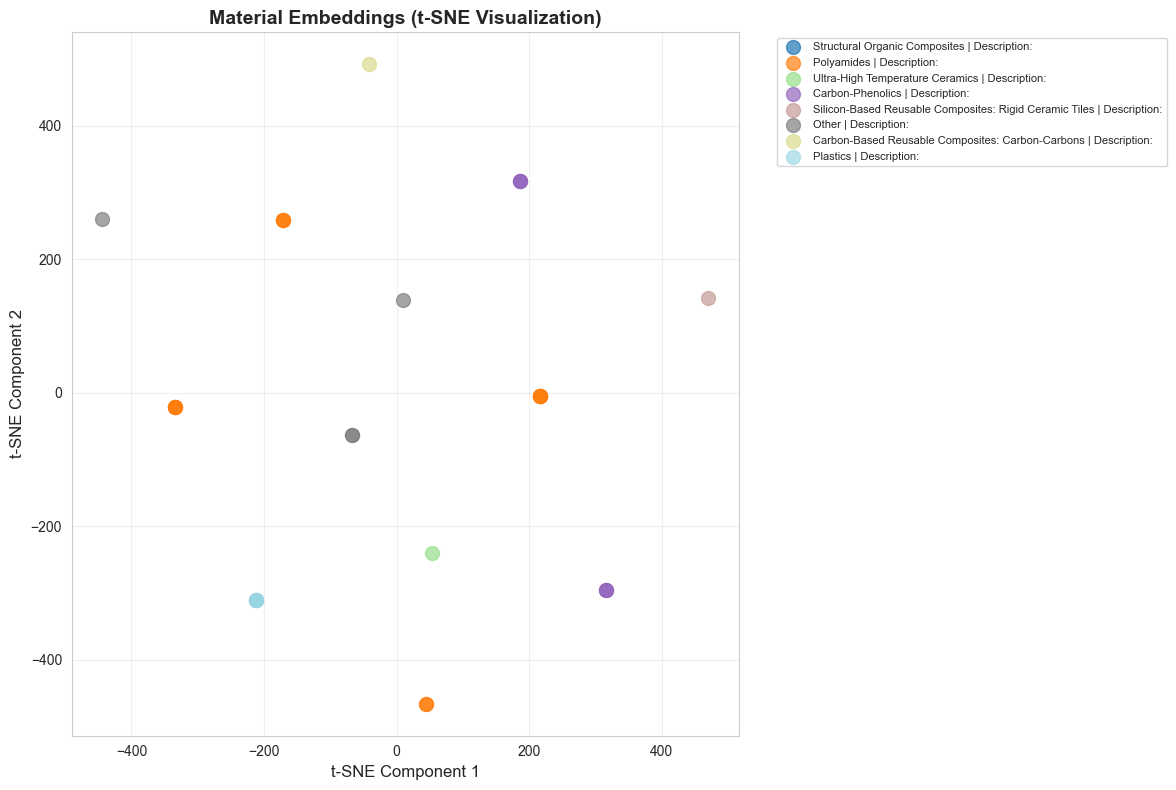

Embedding visualization completed!


In [21]:
# Visualize material embeddings using t-SNE
from sklearn.manifold import TSNE

if data is not None:
    print("=" * 60)
    print("MATERIAL EMBEDDINGS VISUALIZATION")
    print("=" * 60)
    
    # Get embeddings
    model.eval()
    with torch.no_grad():
        embeddings = model(data.x, data.edge_index)
    
    # Convert to numpy
    embeddings_np = embeddings.numpy()
    
    # Apply t-SNE for 2D visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_fe)-1))
    embeddings_2d = tsne.fit_transform(embeddings_np)
    
    # Plot
    plt.figure(figsize=(12, 8))
    
    # Color by category if available
    if 'Category' in df_fe.columns:
        categories = df_fe['Category'].fillna('Unknown')
        unique_cats = categories.unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_cats)))
        cat_to_color = dict(zip(unique_cats, colors))
        
        for cat in unique_cats:
            mask = categories == cat
            plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                       c=[cat_to_color[cat]], label=cat, alpha=0.7, s=100)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    else:
        plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=100)
    
    plt.title('Material Embeddings (t-SNE Visualization)', fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("Embedding visualization completed!")


In [22]:
# Summary Statistics and Model Readiness
print("=" * 60)
print("PROTOTYPE MODEL SUMMARY")
print("=" * 60)

print(f"\nDataset:")
print(f"  - Total materials: {len(df_fe)}")
print(f"  - Total features: {len(df_fe.columns)}")
print(f"  - Properties with data: {len(valid_property_cols)}")

print(f"\nGraph Structure:")
if data is not None:
    print(f"  - Nodes: {data.num_nodes}")
    print(f"  - Edges: {data.num_edges}")
    print(f"  - Node feature dimension: {data.num_node_features}")
    print(f"  - Graph density: {nx.density(G):.4f}")

print(f"\nFeature Engineering:")
print(f"  - Selected properties: {len(selected_properties)}")
print(f"  - Node feature dimension: {node_features.shape[1]}")
print(f"  - Encoded categorical features: {len(categorical_to_encode)}")

print(f"\nModel Architecture:")
if data is not None:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  - Total parameters: {total_params:,}")
    print(f"  - Trainable parameters: {trainable_params:,}")
    print(f"  - Output embedding dimension: 32")

print(f"\n✓ Prototype model is ready for testing!")
print(f"✓ All data preprocessing and graph construction completed successfully!")


PROTOTYPE MODEL SUMMARY

Dataset:
  - Total materials: 30
  - Total features: 260
  - Properties with data: 40

Graph Structure:
  - Nodes: 30
  - Edges: 164
  - Node feature dimension: 19
  - Graph density: 0.1885

Feature Engineering:
  - Selected properties: 14
  - Node feature dimension: 19
  - Encoded categorical features: 4

Model Architecture:
  - Total parameters: 7,520
  - Trainable parameters: 7,520
  - Output embedding dimension: 32

✓ Prototype model is ready for testing!
✓ All data preprocessing and graph construction completed successfully!


## Next Steps

1. **Model Training**: Implement training loop for specific tasks (material property prediction, similarity search, etc.)
2. **Evaluation Metrics**: Define appropriate metrics for material discovery tasks
3. **Hyperparameter Tuning**: Optimize model architecture and training parameters
4. **Production Pipeline**: Integrate with XTRIUM platform for real-world material discovery

## Key Insights

- The dataset contains materials with varying property completeness
- Graph structure captures material similarities based on property values
- GNN embeddings can be used for material similarity search and discovery
- Model is ready for prototyping and testing
